In [1]:
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path

# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent

# Add the 'scripts' directory to sys.path to be able to import data_utils.py
sys.path.append(str(current_dir))

from scripts.data_utils import split_summary_methods, format_mean_std
import ast  
import matplotlib.pyplot as plt
import seaborn as sns
from autorank import autorank, plot_stats, create_report

pd.set_option('display.max_colwidth', None)

/home/nicolas/spectral-benchmark-v2/scripts/data_utils.py:2: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


In [2]:
MAX_NUMBER_OF_RUNS_STOCASTIC = 3

TYPE_WS = "params_with_p_window_size" #params_with_p_window_size or params_with_window

data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pds_and_pv_bv3_bv4.xlsx")

data['cod_scenario'] = data['cod_scenario'].astype(str)

data['method_window_and_param'] = data['method_window_and_param'].str.replace("SWKNN_own", "SWKNN(own)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TNone", "OBKNN (TNone)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TZnorm", "OBKNN (TZNorm)")

data['code_and_name_scenario'] = data['cod_scenario'] +"_"+ data['name_scenario'].astype(str)

data.columns

Index(['iteration', 'cod_scenario', 'name_scenario', 'method_window_and_param',
       'p_window_size', 'window_size', 'raw_roc_auc', 'raw_pr_auc',
       'raw_max_f1', 'raw_roc_auc_wtd', 'raw_pr_auc_wtd', 'raw_max_f1_wtd',
       'raw_pct_detection', 'raw_pct_false_positives', 'tn', 'fp', 'fn', 'tp',
       'best_threshold', 'auc_roc', 'auc_pr', 'precision', 'f_metric',
       'precision_at_k', 'rprecision', 'rrecall', 'rf', 'r_auc_roc',
       'r_auc_pr', 'vus_roc', 'vus_pr', 'affiliation_precision',
       'affiliation_recall', 'mean_training_time', 'max_training_time',
       'min_training_time', 'mean_scoring_time', 'max_scoring_time',
       'min_scoring_time', 'count_cleaned_score', 'count_raw_score',
       'count_anomalies', 'count_normal', 'code_and_name_scenario'],
      dtype='object')

In [3]:
# Find duplicates for the same iteration and the same experiment
duplicates = data[["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].duplicated(keep=False)
data[duplicates][["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].sort_values(by=["method_window_and_param"])

,iteration,cod_scenario,method_window_and_param,count_cleaned_score


In [4]:
# Adjusting format and creating new columns for analysis in the dataset read

# Extracting new columns for the method, window_size, parameters
data[['method',"window_size", 'parameters']] = data['method_window_and_param'].apply(
    lambda x: pd.Series(split_summary_methods(x))
)

# Creating new column params_with_window
data["params_with_p_window_size"] = data["parameters"]
data["params_with_p_window_size"] = data["params_with_p_window_size"].str.replace("}_{", ",", regex=False)

data["params_with_window"] = "{'window_size': " + data["window_size"].astype(str)+data["parameters"].str.replace("{", ", ", regex=False)
data["params_with_window"] = data["params_with_window"].str.replace("}_{", ",", regex=False)

# Define your list of non-stochastic methods
non_stochastic_methods = ["SWKNN", "SWKNN_own", "SWLOF", "KitNet", "ExactStorm"]

# Create the 'stochastic' column
data['stochastic'] = data['method'].apply(
    lambda x: 'N' if x in non_stochastic_methods else 'Y')


# Create the 'public' dataset column
data['public'] = np.where(data['cod_scenario'].str.isdigit(), 'Y', 'N')

# Shortening the name of the methods
new_method_name = {"xStream":"XStream", "RSHash":"RSHash", "IForestASD":"IFASD", "RobustRandomCutForest":"RRCF", "KitNet":"KitNet", "ExactStorm":"EStorm","oIF":"OIF", "HStree":"HStree", "OnlineBootKNN":"OBKNN"} 

data["method"] = data['method'].replace(new_method_name)
data["method_with_param"] = data['method']+"_"+data["parameters"]


is_euc = data['params_with_window'].str.contains('euclidean', case=False, na=False)
is_mah = data['params_with_window'].str.contains('mahalanobis', case=False, na=False)


#Separating OnlineBootKNN with None, Z-normalization 
# Case 1: None
mask_none = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('NONE', case=False, na=False))
data.loc[mask_none, 'method'] = 'OBKNN (None)'

# Case 2: ZNormalization
mask_znorm = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('ZNORM', case=False, na=False))
data.loc[mask_znorm, 'method'] = 'OBKNN (ZNorm)'


# Including the year of publication of the methods
method_and_year = {
"XStream":"2018", "RSHash":"2011", "IFASD":"2013", "RRCF":"2016", "KitNet":"2018", "EStorm":"2007","OIF":"2024", "HStree":"2011", 
"OBKNN (TNone)":"2025", "OBKNN (TZNorm)":"2025", "SWKNN":"2000","SWLOF":"2000"
} 
data["method_and_year"] = data['method'].map(lambda x: f"{x} ({method_and_year.get(x, 'Unknown')})")



In [5]:
#Applying filters to analyse data

regex_filter = "|".join([""])

filtered_data = data[data['method_window_and_param'].str.contains(regex_filter, regex=True)]

# Now, sort the data based on the 'scenario' column
filtered_data = filtered_data.sort_values(by='cod_scenario')


filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["A10","A11","A12"])]# excluded since no detector performs well in these datasets 
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["118","119","120","121","122","123","124","125","126","127","128", "172"])]# excluded since just one dataset of TAO is used (117) for fair comparison among benchmarks
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["019","079","084"])]# excluded since there is no results for OBKNN (ZNORM) because of very small number of features



In [6]:
# 1. Average results over all iterations and all scenarios
averaged_results = filtered_data.groupby(['method', TYPE_WS, 'cod_scenario']).agg(
    mean_auc_pr=('raw_pr_auc', 'mean'),
    mean_precision_at_k=('precision_at_k', 'mean'),
    mean_vus=('vus_pr', 'mean'),
    # You can add std devs here if needed, e.g., std_vus=('vus_pr', 'std')
    n_runs=('raw_pr_auc', 'count')
).reset_index()

# 2. Average results for each method and hyperparameter for all scenarios
summary = averaged_results.groupby(['method', TYPE_WS]).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    mean_precision_at_k=('mean_precision_at_k', 'mean'),
    mean_vus=('mean_vus', 'mean'),
    beetween_std_auc_pr=('mean_auc_pr', 'std'),
    n_scenarios=('mean_auc_pr', 'count')
).reset_index()

# 3. Select the highest AUC_PR per method
best_results = (
    summary
    .sort_values(['mean_auc_pr', 'beetween_std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)

best_params = best_results[TYPE_WS].unique().tolist()
best_results

,method,params_with_p_window_size,mean_auc_pr,mean_precision_at_k,mean_vus,beetween_std_auc_pr,n_scenarios
4,OBKNN (TNone),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",0.535029,0.159265,0.551160,0.454640,31
2,IFASD,"{'initial_window_X': None, 'p_window_size': 0.2}",0.521481,0.267628,0.545870,0.409908,31
3,KitNet,"{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",0.497207,0.078154,0.508099,0.413433,31
0,EStorm,"{'max_radius': 900, 'p_window_size': 0.2}",0.444263,0.001497,0.104997,0.206605,31
6,OIF,"{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",0.392608,0.207680,0.432201,0.355966,31
5,OBKNN (TZNorm),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",0.336333,0.133734,0.367598,0.370094,31
1,HStree,"{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}",0.290128,0.096953,0.307652,0.366365,31
10,XStream,"{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",0.234912,0.054378,0.273733,0.210951,31
8,RSHash,"{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",0.218691,0.002092,0.111632,0.239237,31
9,SWLOF,"{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}",0.129279,0.034565,0.159066,0.086070,31


In [7]:
metrics_per_scenario = filtered_data.groupby(['method', 'cod_scenario']).agg(
    mean_auc=('raw_pr_auc', 'mean'),
    within_std=('raw_pr_auc', 'std')
).reset_index()

summary = metrics_per_scenario.groupby('method').agg(
    mean_auc_pr=('mean_auc', 'mean'),
    between_std_auc_pr=('mean_auc', 'std'),
    within_std_avg=('within_std', 'mean')
).reset_index()

summary['Mean AUC-PR (Within Std)'] = summary.apply(
    lambda row: format_mean_std(row['mean_auc_pr'], row['within_std_avg']),
    axis=1
)

summary['Between Std'] = summary['between_std_auc_pr'].apply(
    lambda x: f"{x:.1e}" if pd.notnull(x) else "N/A"
)

combined = summary[['method', 'Mean AUC-PR (Within Std)', 'Between Std']]
combined = combined.set_index('method').loc[summary.sort_values('mean_auc_pr', ascending=False)['method']]

combined

,Mean AUC-PR (Within Std),Between Std
method,,
OBKNN (TNone),0.535 ± 7.9e-03,4.5e-01
IFASD,0.521 ± 1.1e-02,4.1e-01
KitNet,0.497 ± 0.0e+00,4.1e-01
EStorm,0.444 ± 0.0e+00,2.1e-01
OIF,0.393 ± 4.7e-02,3.6e-01
OBKNN (TZNorm),0.336 ± 3.2e-03,3.7e-01
HStree,0.290 ± 1.8e-02,3.7e-01
XStream,0.235 ± 1.7e-02,2.1e-01
RSHash,0.219 ± 1.8e-03,2.4e-01


In [8]:
metrics_per_scenario = filtered_data.groupby(['method', 'cod_scenario']).agg(
    mean_vus=('vus_pr', 'mean'),
    within_std=('vus_pr', 'std')
).reset_index()

summary = metrics_per_scenario.groupby('method').agg(
    mean_vus_pr=('mean_vus', 'mean'),
    between_std_vus_pr=('mean_vus', 'std'),
    within_std_avg=('within_std', 'mean')
).reset_index()

summary['Mean VUS-PR (Within Std)'] = summary.apply(
    lambda row: format_mean_std(row['mean_vus_pr'], row['within_std_avg']),
    axis=1
)

summary['Between Std'] = summary['between_std_vus_pr'].apply(
    lambda x: f"{x:.1e}" if pd.notnull(x) else "N/A"
)

combined = summary[['method', 'Mean VUS-PR (Within Std)', 'Between Std']]
combined = combined.set_index('method').loc[summary.sort_values('mean_vus_pr', ascending=False)['method']]

combined

,Mean VUS-PR (Within Std),Between Std
method,,
OBKNN (TNone),0.551 ± 8.1e-03,4.5e-01
IFASD,0.546 ± 1.2e-02,4.1e-01
KitNet,0.508 ± 0.0e+00,4.2e-01
OIF,0.432 ± 4.4e-02,3.6e-01
OBKNN (TZNorm),0.368 ± 4.9e-03,3.6e-01
HStree,0.308 ± 1.7e-02,3.8e-01
XStream,0.274 ± 1.9e-02,2.4e-01
SWLOF,0.159 ± 4.5e-05,9.5e-02
RRCF,0.157 ± 1.4e-02,9.2e-02


In [9]:
metrics_list = ['vus_pr', 'vus_roc', 'precision_at_k', 'f_metric' , 'raw_pct_detection','raw_pct_false_positives']

"""
metrics_list = [
    'raw_roc_auc', 'raw_pr_auc', 'raw_max_f1', 'raw_roc_auc_wtd', 
    'raw_pr_auc_wtd', 'raw_max_f1_wtd', 'raw_pct_detection', 
    'raw_pct_false_positives', 'tn', 'fp', 'fn', 'tp', 'best_threshold', 
    'auc_roc', 'auc_pr', 'precision', 'f_metric', 'precision_at_k', 
    'rprecision', 'rrecall', 'rf', 'r_auc_roc', 'r_auc_pr', 'vus_roc', 
    'vus_pr', 'affiliation_precision', 'affiliation_recall', 
    'mean_training_time', 'max_training_time', 'min_training_time', 
    'mean_scoring_time', 'max_scoring_time', 'min_scoring_time', 
    'count_cleaned_score', 'count_raw_score', 'count_anomalies', 'count_normal'
]
"""
metrics_per_scenario = filtered_data.groupby(['method', 'cod_scenario'])[metrics_list].mean()

summary = metrics_per_scenario.groupby('method').mean()

combined = summary.round(4)
combined.columns = "" + combined.columns

combined = combined.loc[summary['vus_pr'].sort_values(ascending=False).index]

combined

,vus_pr,vus_roc,precision_at_k,f_metric,raw_pct_detection,raw_pct_false_positives
method,,,,,,
OBKNN (TNone),0.5512,0.7895,0.1593,0.1802,0.8167,0.2171
IFASD,0.5459,0.8420,0.2676,0.2673,0.7720,0.1810
KitNet,0.5081,0.8186,0.0782,0.0960,0.8122,0.1814
OIF,0.4322,0.7827,0.2077,0.2264,0.7196,0.2943
OBKNN (TZNorm),0.3676,0.6765,0.1337,0.1576,0.7083,0.3013
HStree,0.3077,0.5777,0.0970,0.1336,0.7434,0.4551
XStream,0.2737,0.7463,0.0544,0.0306,0.7433,0.2416
SWLOF,0.1591,0.6537,0.0346,0.0592,0.5289,0.3805
RRCF,0.1567,0.7001,0.0830,0.0782,0.5393,0.4154


## Summary Score of Online Anomaly Detectors (All)

In [10]:
# Filtering just the best hyperparameters
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(best_params)]
#filtered_data = filtered_data[filtered_data["method"].isin(["mDragStream Case 1 (Euc)","mDragStream Case 2 (Euc)","mDragStream Case 3 (Euc)","mDragStream Case 4 (Euc)"])]
best_params

["{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",
 "{'initial_window_X': None, 'p_window_size': 0.2}",
 "{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",
 "{'max_radius': 900, 'p_window_size': 0.2}",
 "{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",
 "{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",
 "{'anomaly_threshold': 0.5, 'max_depth': 10, 'numbe

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
RSHash          7.870968  0.091078  0.077902  0.013176  0.592822         0.0   
HStree          7.580645  0.071910  0.064486    0.0092  0.933616    0.180795   
SWLOF           7.516129  0.115108  0.062332  0.034673  0.262959   -0.229747   
RRCF            7.451613  0.139662  0.046619  0.025115  0.221467   -0.510466   
XStream         6.903226  0.168769  0.140614   0.02752   0.60763    -0.46101   
OBKNN (TZNorm)  6.129032  0.120801  0.100558  0.037907  0.921205   -0.222891   
OIF             5.387097  0.298719  0.247516  0.025444  0.932169   -0.763292   
EStorm          5.064516  0.513482  0.031161  0.050828  0.589286    -4.80223   
KitNet          4.290323  0.405749  0.386488  0.034724  0.996247   -0.761314   
OBKNN (TNone)   4.064516  0.412914  0.410048  0.012934  0.999857   -0.735517   
IFASD           3.741935  0.466595  0.416007  0.050588  0.997974   -0.846323   

                 magnitude effect_size_

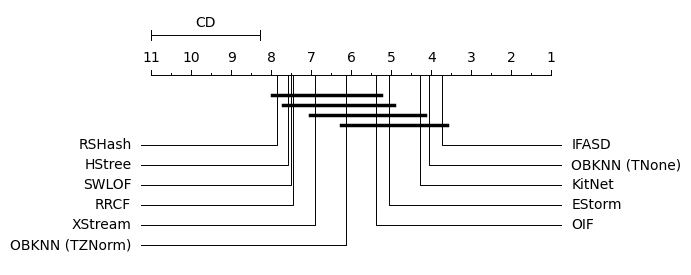

In [11]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_all_data_auc_pr.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
RSHash          8.645161  0.091268  0.067182  0.015358   0.26545         0.0   
EStorm          8.612903  0.127573  0.102208  0.014894  0.255337   -0.283136   
HStree          7.516129  0.095404  0.079437  0.015967  0.962575   -0.037921   
SWLOF           6.903226  0.165149  0.059447  0.036352  0.270644   -0.785596   
RRCF            6.419355  0.152213  0.073558  0.035703  0.301541   -0.583555   
XStream         6.322581  0.205088  0.167501  0.033233  0.676749   -0.601589   
OBKNN (TZNorm)  5.354839  0.207744  0.176376  0.031368  0.920683   -0.588663   
OIF             4.645161  0.326483  0.287418  0.034934  0.981454   -0.760136   
KitNet          4.419355  0.431448  0.407571  0.028586   0.99661   -0.785552   
OBKNN (TNone)   3.870968  0.538990   0.46041  0.019934  0.999924   -0.917867   
IFASD           3.290323  0.526711  0.440115  0.038644  0.999787   -0.932943   

                 magnitude effect_size_

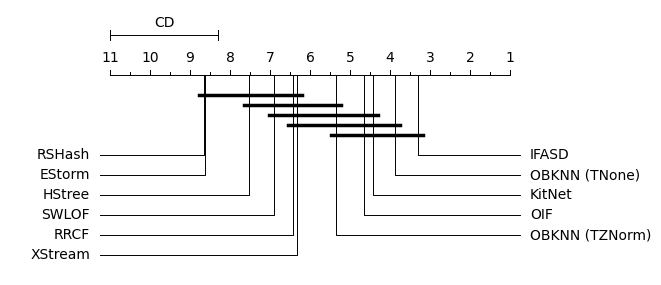

In [12]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_all_data_vus_pr.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

## Summary Score and Time Computation of Online Anomaly Detectors (Spectral DS)

In [13]:
#Applying filters to analyse data

#regex_filter = "|".join(["'transf': 'None'", "shingle_size",'SWKNN'])
regex_filter = "|".join([""])

filtered_data = data[data['method_window_and_param'].str.contains(regex_filter, regex=True)]
filtered_data = filtered_data[filtered_data['public'] == 'N']

# Filter rows where 'parameters' column contains any of the best_params
#filtered_data = filtered_data[filtered_data['params_with_window'].isin(best_params)]


#filtered_data = filtered_data[filtered_data['method'].str.contains("std_p")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("None|FOD|SOD|DIL|QUANT")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("QUANT")]
#filtered_data = filtered_data[filtered_data.method.str.contains("OnlineBootGP|OnlineBootKNN")]

# Now, sort the data based on the 'scenario' column
filtered_data = filtered_data.sort_values(by='cod_scenario')

#filtered_data = filtered_data[~filtered_data.window_size.isin(["60"])]

#filtered_data = filtered_data[filtered_data.method.isin(["ExactStorm", "OnlineBootKNN"])]
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["A10","A11","A12"])]# excluded since no detector performs well in these datasets 
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["118","119","120","121","122","123","124","125","126","127","128", "172"])]# excluded since just one dataset of TAO is used (117) for fair comparison among benchmarks
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["019","079","084"])]# excluded since there is no results for OBKNN (ZNORM) because of very small number of features

#filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR","TNH","TAR","RNH","RAR","RMX","SAR1","SAR2","SAR3","A10","A11","A12"])]

#filtered_data = filtered_data[filtered_data.scenario.isin(["A1", "A2","A3","A4", "A5","A6","A7", "A8","A9"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["DA2","137"])] 
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR"])] 
#filtered_data = filtered_data[filtered_data.scenario.isin(["TA1", "TA2","TA3", "DA3"])]
#filtered_data = filtered_data[~filtered_data.scenario.isin(["SWaT","PSM","CreditCard","172"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["RMX"])]


#filtered_data = filtered_data[filtered_data['method_window_and_param'].isin(PARAMS)]
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(hyperparameters_complete)]

#total_scenarios = len(filtered_data.scenario.unique())
# Compute overall mean, std, and count across all datasets
# Exclude the rows where the number of scenarios is not equal to total_scenarios
#summary = summary[summary.n_scenarios==total_scenarios]

#filtered_data.head(10)
#filtered_data.to_excel("/home/nicolas/spectral_anomaly_detector/datasets/summaries/summary_results_sota_and_dragstream_method_eval_pds.xlsx")

In [14]:
dataset_summary = filtered_data.groupby('code_and_name_scenario').agg(
    total_normal=('count_normal', 'max'),
    abn_instances=('count_anomalies', 'max')
).reset_index()

dataset_summary['code_and_name_scenario'] = dataset_summary['code_and_name_scenario'].astype(str).str.strip()

temporal_list = ['TA1_20250604', 'TA2_20250606', 'TA3_20250605']

dataset_summary['anomaly_type_pattern'] = 'Spatial'
dataset_summary.loc[dataset_summary['code_and_name_scenario'].isin(temporal_list), 'anomaly_type_pattern'] = 'Temporal'

dataset_summary['wavelengths (features)'] = 2048
dataset_summary['total_instances'] = dataset_summary['abn_instances'] + dataset_summary['total_normal']
dataset_summary['anomaly_percentage'] = (dataset_summary['abn_instances'] / dataset_summary['total_instances']) * 100

dataset_summary = dataset_summary[
    ['code_and_name_scenario', 'anomaly_type_pattern', 'wavelengths (features)', 'abn_instances', 'total_instances', 'anomaly_percentage']
]

dataset_summary

,code_and_name_scenario,anomaly_type_pattern,wavelengths (features),abn_instances,total_instances,anomaly_percentage
0,A1_20241023,Spatial,2048,60,4200,1.428571
1,A2_20241024,Spatial,2048,300,4200,7.142857
2,A3_20241024,Spatial,2048,600,4200,14.285714
3,A4_20241002,Spatial,2048,60,4200,1.428571
4,A5_20241002,Spatial,2048,300,4200,7.142857
5,A6_20241002,Spatial,2048,600,4200,14.285714
6,A7_20241004,Spatial,2048,60,4200,1.428571
7,A8_20241004,Spatial,2048,300,4200,7.142857
8,A9_20241004,Spatial,2048,600,4200,14.285714
9,DA1_20250609,Spatial,2048,60,4200,1.428571


In [15]:

# 1. Pivot: REMOVED 'window_size'
# The pivot will now calculate the mean/std across all window sizes automatically.

mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index=["code_and_name_scenario"],                           # <--- Rows: Datasets
    columns=["method_and_year", "parameters"],   # <--- Cols: Methods & Params only
    aggfunc="mean"
)

std_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index=["code_and_name_scenario"],
    columns=["method_and_year", "parameters"],
    aggfunc="std"
)

# 2. Stack: We strictly have 2 levels of columns now
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Format strings
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack: Restore the 2 column levels
combined = combined_s.unstack(level=[-2, -1])

# --- 5. HANDLING AVERAGES & SORTING ---

# Calculate the numeric average for the columns (axis=0)
avg_mean = mean_pivot.mean(axis=0)
avg_std = std_pivot.mean(axis=0)

# Sort columns by the method's average performance
sorted_columns = avg_mean.sort_values(ascending=False).index
combined = combined[sorted_columns]

# Format the Average Row
avg_row_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

# Add the "Avg" Row to the bottom
combined.loc['Average', :] = avg_row_s

# Display
combined

/tmp/ipykernel_1495289/625345094.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_1495289/625345094.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


method_and_year,OBKNN (TNone) (2025),IFASD (2013),KitNet (2018),EStorm (2007),OIF (2024),HStree (2011),OBKNN (TZNorm) (2025),XStream (2018),RSHash (2011),SWLOF (2000),RRCF (2016)
parameters,"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}","{'initial_window_X': None, 'p_window_size': 0.2}","{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}","{'max_radius': 900, 'p_window_size': 0.2}","{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}","{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}","{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}","{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}","{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}","{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}"
code_and_name_scenario,,,,,,,,,,,
A1_20241023,0.976 ± 1.5e-05,0.977 ± 1.1e-02,0.948 ± 0.0e+00,0.509 ± 0.0e+00,0.983 ± 5.5e-04,0.613 ± 1.9e-01,0.925 ± 6.5e-03,0.173 ± 2.6e-02,0.509 ± 0.0e+00,0.215 ± 0.0e+00,0.134 ± 7.1e-03
A2_20241024,1.000 ± 0.0e+00,1.000 ± 1.3e-04,0.998 ± 0.0e+00,0.545 ± 0.0e+00,0.925 ± 5.8e-02,0.875 ± 9.2e-04,0.944 ± 9.0e-04,0.608 ± 7.5e-02,0.546 ± 0.0e+00,0.101 ± 0.0e+00,0.118 ± 1.8e-02
A3_20241024,1.000 ± 2.0e-06,0.859 ± 3.9e-03,0.999 ± 0.0e+00,0.589 ± 0.0e+00,0.339 ± 8.5e-02,0.940 ± 3.6e-03,0.752 ± 3.7e-04,0.600 ± 2.7e-02,0.593 ± 0.0e+00,0.151 ± 0.0e+00,0.221 ± 6.6e-02
A4_20241002,0.930 ± 0.0e+00,0.933 ± 8.0e-03,0.527 ± 0.0e+00,0.509 ± 0.0e+00,0.927 ± 5.2e-03,0.019 ± 1.2e-02,0.921 ± 1.7e-03,0.218 ± 5.5e-03,0.013 ± 0.0e+00,0.229 ± 0.0e+00,0.147 ± 1.4e-02
A5_20241002,1.000 ± 0.0e+00,1.000 ± 3.8e-05,0.993 ± 0.0e+00,0.545 ± 0.0e+00,0.762 ± 1.9e-01,0.769 ± 2.7e-02,0.897 ± 3.0e-03,0.470 ± 5.8e-02,0.582 ± 0.0e+00,0.125 ± 0.0e+00,0.158 ± 4.3e-03
A6_20241002,1.000 ± 1.6e-06,0.857 ± 8.8e-03,0.905 ± 0.0e+00,0.589 ± 0.0e+00,0.351 ± 1.1e-01,0.934 ± 4.0e-03,0.704 ± 1.0e-03,0.536 ± 1.2e-02,0.623 ± 0.0e+00,0.182 ± 0.0e+00,0.203 ± 3.7e-03
A7_20241004,0.999 ± 0.0e+00,0.962 ± 1.8e-02,0.543 ± 0.0e+00,0.509 ± 0.0e+00,0.932 ± 5.1e-03,0.011 ± 2.7e-03,0.903 ± 2.0e-03,0.249 ± 8.0e-03,0.513 ± 0.0e+00,0.297 ± 0.0e+00,0.195 ± 4.0e-02
A8_20241004,0.999 ± 4.8e-04,0.998 ± 1.2e-03,0.996 ± 0.0e+00,0.545 ± 0.0e+00,0.835 ± 1.3e-01,0.734 ± 1.0e-03,0.821 ± 1.0e-02,0.422 ± 1.6e-02,0.546 ± 0.0e+00,0.102 ± 0.0e+00,0.145 ± 8.9e-03


                meanrank    median       mad  ci_lower  ci_upper effect_size  \
SWLOF           8.764706  0.151031   0.05003  0.039538  0.297089         0.0   
RRCF            8.470588  0.147157  0.044496  0.044125  0.221911    0.055192   
RSHash          8.176471  0.307531   0.23888   0.01082  0.623457   -0.611654   
XStream         7.882353  0.309383  0.160727  0.039726  0.624692   -0.897316   
OBKNN (TZNorm)  6.235294  0.704484  0.239286   0.03938  0.943769   -2.159554   
HStree          6.117647  0.612699  0.325977  0.010984  0.940486     -1.3353   
OIF             5.529412  0.440230  0.351714  0.051203  0.983351   -0.776515   
EStorm          5.470588  0.544643  0.035714  0.508333  0.589286   -6.108015   
KitNet          4.588235  0.914371  0.083432  0.040056  0.999387     -7.4847   
IFASD           2.823529  0.932575  0.067291  0.077139  0.999875   -8.890646   
OBKNN (TNone)   1.941176  0.990785  0.009072    0.0774  0.999984  -15.753961   

                 magnitude effect_size_

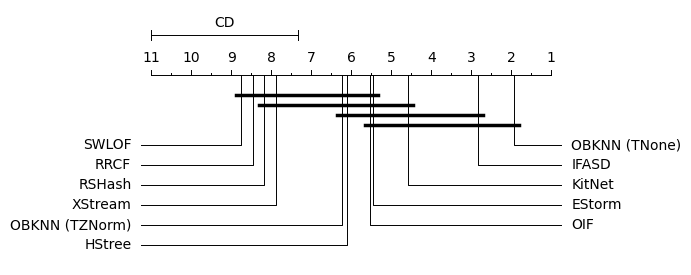

In [16]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_sd_auc_pr.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

In [17]:

# 1. Pivot: REMOVED 'window_size'
# The pivot will now calculate the mean/std across all window sizes automatically.

mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],                           # <--- Rows: Datasets
    columns=["method_and_year", "parameters"],   # <--- Cols: Methods & Params only
    aggfunc="mean"
)

std_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],
    columns=["method_and_year", "parameters"],
    aggfunc="std"
)

# 2. Stack: We strictly have 2 levels of columns now
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Format strings
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack: Restore the 2 column levels
combined = combined_s.unstack(level=[-2, -1])

# --- 5. HANDLING AVERAGES & SORTING ---

# Calculate the numeric average for the columns (axis=0)
avg_mean = mean_pivot.mean(axis=0)
avg_std = std_pivot.mean(axis=0)

# Sort columns by the method's average performance
sorted_columns = avg_mean.sort_values(ascending=False).index
combined = combined[sorted_columns]

# Format the Average Row
avg_row_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

# Add the "Avg" Row to the bottom
combined.loc['Average', :] = avg_row_s

# Display
combined

/tmp/ipykernel_1495289/3862296360.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_1495289/3862296360.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


method_and_year,OBKNN (TNone) (2025),IFASD (2013),KitNet (2018),OIF (2024),OBKNN (TZNorm) (2025),HStree (2011),XStream (2018),SWLOF (2000),RRCF (2016),RSHash (2011),EStorm (2007)
parameters,"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}","{'initial_window_X': None, 'p_window_size': 0.2}","{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}","{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}","{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}","{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}","{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}","{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}","{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}","{'max_radius': 900, 'p_window_size': 0.2}"
code_and_name_scenario,,,,,,,,,,,
A1_20241023,0.990 ± 7.0e-07,0.992 ± 9.7e-04,0.987 ± 0.0e+00,0.991 ± 1.1e-03,0.921 ± 8.0e-03,0.626 ± 1.9e-01,0.205 ± 2.4e-02,0.221 ± 0.0e+00,0.145 ± 1.2e-02,0.026 ± 0.0e+00,0.025 ± 0.0e+00
A2_20241024,1.000 ± 8.3e-05,1.000 ± 5.6e-06,0.999 ± 0.0e+00,0.943 ± 4.8e-02,0.942 ± 1.1e-03,0.901 ± 2.3e-03,0.721 ± 9.5e-02,0.186 ± 0.0e+00,0.172 ± 2.2e-02,0.133 ± 0.0e+00,0.128 ± 0.0e+00
A3_20241024,1.000 ± 0.0e+00,0.883 ± 3.4e-03,1.000 ± 0.0e+00,0.551 ± 8.6e-02,0.782 ± 3.7e-04,0.968 ± 2.1e-03,0.677 ± 5.7e-03,0.225 ± 0.0e+00,0.322 ± 8.6e-02,0.265 ± 0.0e+00,0.255 ± 0.0e+00
A4_20241002,0.995 ± 0.0e+00,0.994 ± 8.0e-04,0.613 ± 0.0e+00,0.981 ± 5.9e-03,0.980 ± 3.2e-03,0.022 ± 1.3e-02,0.311 ± 3.1e-02,0.362 ± 0.0e+00,0.181 ± 4.7e-03,0.015 ± 0.0e+00,0.025 ± 0.0e+00
A5_20241002,1.000 ± 3.1e-05,1.000 ± 8.2e-06,0.992 ± 0.0e+00,0.814 ± 1.7e-01,0.895 ± 3.2e-03,0.812 ± 2.2e-02,0.544 ± 4.3e-02,0.200 ± 0.0e+00,0.226 ± 8.2e-03,0.234 ± 0.0e+00,0.128 ± 0.0e+00
A6_20241002,1.000 ± 4.1e-07,0.895 ± 4.5e-03,0.917 ± 0.0e+00,0.560 ± 1.1e-01,0.773 ± 1.6e-03,0.963 ± 3.7e-03,0.661 ± 1.3e-02,0.267 ± 0.0e+00,0.302 ± 1.3e-02,0.353 ± 0.0e+00,0.255 ± 0.0e+00
A7_20241004,0.994 ± 1.0e-03,0.968 ± 1.8e-02,0.499 ± 0.0e+00,0.940 ± 1.3e-02,0.892 ± 4.4e-03,0.016 ± 3.7e-03,0.292 ± 1.0e-02,0.321 ± 0.0e+00,0.180 ± 3.9e-02,0.036 ± 0.0e+00,0.025 ± 0.0e+00
A8_20241004,0.999 ± 3.7e-04,1.000 ± 5.6e-05,0.996 ± 0.0e+00,0.861 ± 1.2e-01,0.830 ± 8.3e-03,0.782 ± 2.3e-03,0.523 ± 1.3e-02,0.165 ± 0.0e+00,0.212 ± 1.8e-02,0.133 ± 0.0e+00,0.128 ± 0.0e+00


                meanrank    median       mad  ci_lower  ci_upper effect_size  \
EStorm          9.647059  0.127573  0.102208  0.023674  0.255337         0.0   
RSHash          9.352941  0.132626  0.106256  0.013272   0.44465   -0.032688   
SWLOF           7.588235  0.208826  0.058536  0.057939  0.362135   -0.658026   
RRCF            7.411765  0.179859  0.035278  0.053525   0.32173   -0.461262   
XStream         6.882353  0.372589  0.195749   0.04023  0.720693   -1.058365   
HStree          6.176471  0.625678  0.339621  0.015967  0.967796   -1.339646   
OBKNN (TZNorm)  5.411765  0.773081  0.207341  0.053119  0.980422   -2.663621   
OIF             4.588235  0.613901   0.27288  0.061049  0.991003   -1.591989   
KitNet          4.470588  0.922869  0.075947  0.043091  0.999869   -5.957568   
IFASD           2.647059  0.967971  0.031885  0.112665  0.999962   -7.487267   
OBKNN (TNone)   1.823529  0.995034  0.004882  0.115079  0.999994   -8.086495   

                 magnitude effect_size_

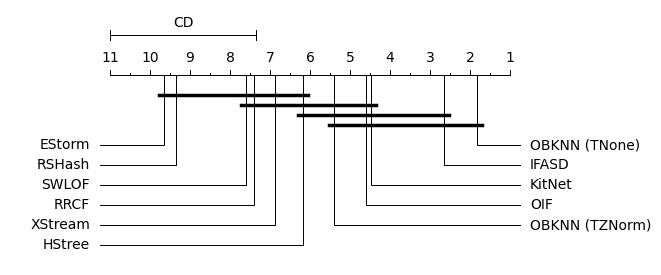

In [18]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_sd_vus_pr.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

In [19]:
filtered_data.columns

Index(['iteration', 'cod_scenario', 'name_scenario', 'method_window_and_param',
       'p_window_size', 'window_size', 'raw_roc_auc', 'raw_pr_auc',
       'raw_max_f1', 'raw_roc_auc_wtd', 'raw_pr_auc_wtd', 'raw_max_f1_wtd',
       'raw_pct_detection', 'raw_pct_false_positives', 'tn', 'fp', 'fn', 'tp',
       'best_threshold', 'auc_roc', 'auc_pr', 'precision', 'f_metric',
       'precision_at_k', 'rprecision', 'rrecall', 'rf', 'r_auc_roc',
       'r_auc_pr', 'vus_roc', 'vus_pr', 'affiliation_precision',
       'affiliation_recall', 'mean_training_time', 'max_training_time',
       'min_training_time', 'mean_scoring_time', 'max_scoring_time',
       'min_scoring_time', 'count_cleaned_score', 'count_raw_score',
       'count_anomalies', 'count_normal', 'code_and_name_scenario', 'method',
       'parameters', 'params_with_p_window_size', 'params_with_window',
       'stochastic', 'public', 'method_with_param', 'method_and_year'],
      dtype='object')

In [20]:
metrics_list = ['mean_training_time','max_training_time', 'mean_scoring_time','max_scoring_time']

metrics_per_scenario = filtered_data.groupby(['method', 'parameters', 'cod_scenario'])[metrics_list].mean()

summary = metrics_per_scenario.groupby(['method', 'parameters']).mean()

combined = summary.round(4)
combined.columns = "" + combined.columns

combined = combined.loc[summary['mean_training_time'].sort_values(ascending=False).index]

combined

,,mean_training_time,max_training_time,mean_scoring_time,max_scoring_time
method,parameters,,,,
OIF,"{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",0.1600,0.9920,0.0233,0.1573
XStream,"{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",0.1018,0.3648,0.0973,0.1110
KitNet,"{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",0.0979,0.3428,0.0906,0.1196
IFASD,"{'initial_window_X': None, 'p_window_size': 0.2}",0.0264,0.2705,0.0050,0.0058
RRCF,"{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}",0.0124,0.1467,0.0005,0.0132
OBKNN (TZNorm),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",0.0112,0.0266,0.0351,0.3466
OBKNN (TNone),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",0.0103,0.0412,0.0350,0.3693
RSHash,"{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",0.0036,0.0044,0.0000,0.0000
EStorm,"{'max_radius': 900, 'p_window_size': 0.2}",0.0025,0.0028,0.0037,0.0045


## Summary Score and Time Computation of Online Anomaly Detectors (Multivariate DS)

In [21]:
#Applying filters to analyse data

#regex_filter = "|".join(["'transf': 'None'", "shingle_size",'SWKNN'])
regex_filter = "|".join([""])

filtered_data = data[data['method_window_and_param'].str.contains(regex_filter, regex=True)]
filtered_data = filtered_data[filtered_data['public'] == 'Y']

# Filter rows where 'parameters' column contains any of the best_params
#filtered_data = filtered_data[filtered_data['params_with_window'].isin(best_params)]


#filtered_data = filtered_data[filtered_data['method'].str.contains("std_p")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("None|FOD|SOD|DIL|QUANT")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("QUANT")]
#filtered_data = filtered_data[filtered_data.method.str.contains("OnlineBootGP|OnlineBootKNN")]

# Now, sort the data based on the 'scenario' column
filtered_data = filtered_data.sort_values(by='cod_scenario')

#filtered_data = filtered_data[~filtered_data.window_size.isin(["60"])]

#filtered_data = filtered_data[filtered_data.method.isin(["ExactStorm", "OnlineBootKNN"])]
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["A10","A11","A12"])]# excluded since no detector performs well in these datasets 
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["118","119","120","121","122","123","124","125","126","127","128", "172"])]# excluded since just one dataset of TAO is used (117) for fair comparison among benchmarks
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["019","079","084"])]# 019 MITDB, 079 LTDB, 084 SVDB: excluded since there is no results for OBKNN (ZNORM) because of very small number of features (2D)

#filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR","TNH","TAR","RNH","RAR","RMX","SAR1","SAR2","SAR3","A10","A11","A12"])]

#filtered_data = filtered_data[filtered_data.scenario.isin(["A1", "A2","A3","A4", "A5","A6","A7", "A8","A9"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["DA2","137"])] 
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR"])] 
#filtered_data = filtered_data[filtered_data.scenario.isin(["TA1", "TA2","TA3", "DA3"])]
#filtered_data = filtered_data[~filtered_data.scenario.isin(["SWaT","PSM","CreditCard","172"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["RMX"])]


#filtered_data = filtered_data[filtered_data['method_window_and_param'].isin(PARAMS)]
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(hyperparameters_complete)]

#total_scenarios = len(filtered_data.scenario.unique())
# Compute overall mean, std, and count across all datasets
# Exclude the rows where the number of scenarios is not equal to total_scenarios
#summary = summary[summary.n_scenarios==total_scenarios]

#filtered_data.head(10)
#filtered_data.to_excel("/home/nicolas/spectral_anomaly_detector/datasets/summaries/summary_results_sota_and_dragstream_method_eval_pds.xlsx")

In [22]:

dataset_summary = filtered_data.groupby('code_and_name_scenario').agg(
    total_normal=('count_normal', 'max'),
    abn_instances=('count_anomalies', 'max')
).reset_index()

dataset_summary['total_instances'] = dataset_summary['abn_instances'] + dataset_summary['total_normal']
dataset_summary['anomaly_percentage'] = (dataset_summary['abn_instances'] / dataset_summary['total_instances']) * 100

dataset_info = {
    'GHL': {'anomaly_type_len': 'Sequence', 'features': 19},
    'Daphnet': {'anomaly_type_len': 'Sequence', 'features': 9},
    'Exathlon': {'anomaly_type_len': 'Sequence', 'features': 18},
    'Genesis': {'anomaly_type_len': 'Sequence', 'features': 18},
    'OPP': {'anomaly_type_len': 'Sequence', 'features': 248},
    'SMD': {'anomaly_type_len': 'Sequence', 'features': 38},
    'SWaT': {'anomaly_type_len': 'Sequence', 'features': 66},
    'PSM': {'anomaly_type_len': 'Point&Seq.', 'features': 25},
    'SMAP': {'anomaly_type_len': 'Sequence', 'features': 25},
    'MSL': {'anomaly_type_len': 'Sequence', 'features': 55},
    'CreditCard': {'anomaly_type_len': 'Point&Seq.', 'features': 29},
    'GECCO': {'anomaly_type_len': 'Sequence', 'features': 9},
    'MITDB': {'anomaly_type_len': 'Sequence', 'features': 2},
    'SVDB': {'anomaly_type_len': 'Sequence', 'features': 2},
    'LTDB': {'anomaly_type_len': 'Sequence', 'features': 2},
    'CATSv2': {'anomaly_type_len': 'Sequence', 'features': 17},
    'TAO': {'anomaly_type_len': 'Point&Seq.', 'features': 3}
}

ordered_list = list(dataset_info.keys())

dataset_summary['matched_dataset'] = dataset_summary['code_and_name_scenario'].str.split('_').str[-1]
dataset_summary['matched_dataset'] = dataset_summary['matched_dataset'].replace({'OPPORTUNITY': 'OPP'})

for col in ['anomaly_type_len', 'features']:
    dataset_summary[col] = dataset_summary['matched_dataset'].map(
        lambda x: dataset_info[x][col] if x in dataset_info else pd.NA
    )

dataset_summary['matched_dataset'] = pd.Categorical(
    dataset_summary['matched_dataset'], 
    categories=ordered_list, 
    ordered=True
)

dataset_summary = dataset_summary.dropna(subset=['matched_dataset'])
dataset_summary = dataset_summary.sort_values('matched_dataset')

dataset_summary = dataset_summary[
    ['code_and_name_scenario', 'anomaly_type_len', 'features', 'abn_instances', 'total_instances', 'anomaly_percentage']
].reset_index(drop=True)

dataset_summary

,code_and_name_scenario,anomaly_type_len,features,abn_instances,total_instances,anomaly_percentage
0,032_GHL,Sequence,19,1850,200001,0.924995
1,018_Daphnet,Sequence,9,2306,38774,5.947284
2,174_Exathlon,Sequence,18,5437,43066,12.624808
3,001_Genesis,Sequence,18,50,16220,0.308261
4,129_OPPORTUNITY,Sequence,248,721,24693,2.919856
5,057_SMD,Sequence,38,542,23694,2.287499
6,171_SWaT,Sequence,66,1986,14996,13.243532
7,115_PSM,Point&Seq.,25,24381,217624,11.203268
8,144_SMAP,Sequence,25,1121,8209,13.655744
9,002_MSL,Sequence,55,11,1827,0.602080


In [23]:

# 1. Pivot: REMOVED 'window_size'
# The pivot will now calculate the mean/std across all window sizes automatically.

mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index=["code_and_name_scenario"],                           # <--- Rows: Datasets
    columns=["method_and_year", "parameters"],   # <--- Cols: Methods & Params only
    aggfunc="mean"
)

std_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index=["code_and_name_scenario"],
    columns=["method_and_year", "parameters"],
    aggfunc="std"
)

# 2. Stack: We strictly have 2 levels of columns now
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Format strings
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack: Restore the 2 column levels
combined = combined_s.unstack(level=[-2, -1])

# --- 5. HANDLING AVERAGES & SORTING ---

# Calculate the numeric average for the columns (axis=0)
avg_mean = mean_pivot.mean(axis=0)
avg_std = std_pivot.mean(axis=0)

# Sort columns by the method's average performance
sorted_columns = avg_mean.sort_values(ascending=False).index
combined = combined[sorted_columns]

# Format the Average Row
avg_row_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

# Add the "Avg" Row to the bottom
combined.loc['Average', :] = avg_row_s

# Display
combined

/tmp/ipykernel_1495289/625345094.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_1495289/625345094.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


method_and_year,EStorm (2007),KitNet (2018),IFASD (2013),OIF (2024),OBKNN (TNone) (2025),OBKNN (TZNorm) (2025),XStream (2018),RSHash (2011),SWLOF (2000),RRCF (2016),HStree (2011)
parameters,"{'max_radius': 900, 'p_window_size': 0.2}","{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}","{'initial_window_X': None, 'p_window_size': 0.2}","{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}","{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}","{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}","{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}","{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}","{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}"
code_and_name_scenario,,,,,,,,,,,
001_Genesis,0.002 ± 0.0e+00,0.012 ± 0.0e+00,0.006 ± 5.7e-04,0.005 ± 1.7e-03,0.003 ± 4.2e-04,0.020 ± 7.8e-04,0.015 ± 8.4e-04,0.003 ± 0.0e+00,0.014 ± 6.2e-07,0.074 ± 3.5e-02,0.009 ± 3.7e-03
002_MSL,0.504 ± 0.0e+00,0.019 ± 0.0e+00,0.016 ± 3.4e-03,0.014 ± 5.7e-03,0.013 ± 1.3e-03,0.053 ± 1.4e-02,0.017 ± 8.5e-03,0.016 ± 0.0e+00,0.019 ± 0.0e+00,0.033 ± 4.3e-03,0.003 ± 7.6e-05
018_Daphnet,0.049 ± 0.0e+00,0.291 ± 0.0e+00,0.266 ± 1.1e-02,0.117 ± 2.7e-03,0.063 ± 8.4e-04,0.076 ± 4.9e-04,0.032 ± 4.5e-05,0.041 ± 0.0e+00,0.115 ± 1.3e-05,0.097 ± 1.5e-03,0.036 ± 1.6e-04
032_GHL,0.506 ± 0.0e+00,0.009 ± 0.0e+00,0.006 ± 4.1e-04,0.007 ± 5.1e-04,0.010 ± 1.2e-04,0.009 ± 7.5e-06,0.019 ± 3.6e-03,0.507 ± 0.0e+00,0.011 ± 0.0e+00,0.012 ± 3.0e-04,0.007 ± 1.2e-03
057_SMD,0.513 ± 0.0e+00,0.278 ± 0.0e+00,0.267 ± 9.7e-03,0.179 ± 2.7e-02,0.242 ± 4.1e-02,0.259 ± 2.5e-04,0.321 ± 1.7e-02,0.015 ± 3.7e-05,0.052 ± 0.0e+00,0.060 ± 5.4e-03,0.012 ± 4.2e-05
115_PSM,0.570 ± 0.0e+00,0.146 ± 0.0e+00,0.154 ± 2.6e-03,0.183 ± 2.3e-03,0.167 ± 7.9e-03,0.163 ± 8.8e-04,0.100 ± 8.2e-03,0.160 ± 4.6e-02,0.126 ± 0.0e+00,0.145 ± 1.4e-03,0.072 ± 6.7e-03
117_TAO,0.569 ± 0.0e+00,0.981 ± 0.0e+00,0.636 ± 5.1e-02,1.000 ± 0.0e+00,0.961 ± 3.5e-03,0.897 ± 4.5e-02,0.624 ± 5.0e-02,0.073 ± 3.3e-05,0.348 ± 2.4e-03,0.263 ± 3.4e-02,0.073 ± 8.9e-05
129_OPPORTUNITY,0.051 ± 0.0e+00,0.017 ± 0.0e+00,0.051 ± 1.6e-02,0.025 ± 1.0e-02,0.010 ± 5.1e-04,0.010 ± 1.0e-04,0.046 ± 4.2e-03,0.027 ± 0.0e+00,0.035 ± 0.0e+00,0.021 ± 3.9e-03,0.018 ± 1.5e-03


                meanrank    median       mad  ci_lower  ci_upper effect_size  \
HStree          9.357143  0.018794  0.016592  0.000903  0.242948         0.0   
RSHash          7.500000  0.034005  0.032147  0.000846  0.506623   -0.401074   
OBKNN (TNone)   6.642857  0.050203  0.046969  0.002867  0.960671   -0.601454   
RRCF            6.214286  0.067206  0.047868  0.012421  0.263181   -0.911514   
OBKNN (TZNorm)  6.000000  0.064435  0.054829  0.008932  0.896772   -0.759995   
SWLOF           6.000000  0.058915  0.046292  0.011493  0.347887   -0.778231   
XStream         5.714286  0.066619   0.04612   0.01505  0.623825    -0.93075   
OIF             5.214286  0.148324  0.128564  0.004733       1.0   -0.953137   
IFASD           4.857143  0.148484  0.130474   0.00612  0.883469    -0.94057   
EStorm          4.571429  0.504772  0.079283  0.002224  0.585338   -5.722963   
KitNet          3.928571  0.154425  0.135862  0.009008   0.98121   -0.945233   

                 magnitude effect_size_

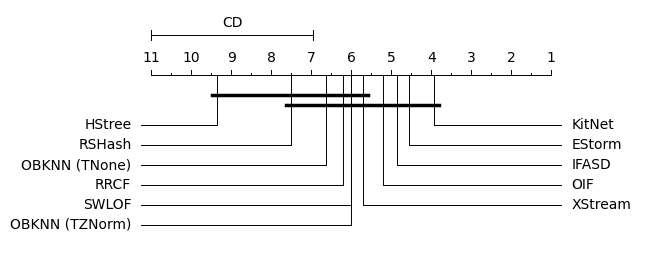

In [24]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_public_data_auc_pr.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
HStree          9.142857  0.030475  0.023058  0.001313  0.185339         0.0   
RSHash          7.785714  0.034664  0.025555  0.001058  0.257514   -0.116093   
EStorm          7.357143  0.044510  0.037246  0.001694  0.244133   -0.305622   
OBKNN (TNone)   6.357143  0.064741  0.061114  0.003343  0.924084   -0.500393   
SWLOF           6.071429  0.060447  0.042469  0.013628  0.220034    -0.59162   
XStream         5.642857  0.051586  0.032957    0.0168  0.604501   -0.500655   
OBKNN (TZNorm)  5.285714  0.087514  0.073957  0.007887  0.844551   -0.702332   
RRCF            5.214286  0.076200   0.05544   0.01251  0.277073   -0.726411   
OIF             4.714286  0.154833  0.133778  0.006714  0.999604   -0.873824   
KitNet          4.357143  0.088124  0.078149  0.008791   0.99661   -0.674899   
IFASD           4.071429  0.136443  0.128118  0.007826  0.914347   -0.776483   

                 magnitude effect_size_

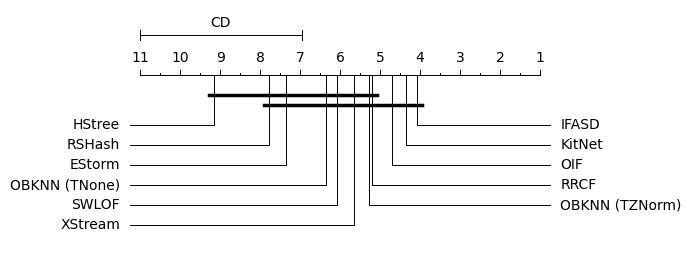

In [25]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_public_data_vus_pr.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

In [26]:

# 1. Pivot: REMOVED 'window_size'
# The pivot will now calculate the mean/std across all window sizes automatically.

mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],                           # <--- Rows: Datasets
    columns=["method_and_year", "parameters"],   # <--- Cols: Methods & Params only
    aggfunc="mean"
)

std_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],
    columns=["method_and_year", "parameters"],
    aggfunc="std"
)

# 2. Stack: We strictly have 2 levels of columns now
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Format strings
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack: Restore the 2 column levels
combined = combined_s.unstack(level=[-2, -1])

# --- 5. HANDLING AVERAGES & SORTING ---

# Calculate the numeric average for the columns (axis=0)
avg_mean = mean_pivot.mean(axis=0)
avg_std = std_pivot.mean(axis=0)

# Sort columns by the method's average performance
sorted_columns = avg_mean.sort_values(ascending=False).index
combined = combined[sorted_columns]

# Format the Average Row
avg_row_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

# Add the "Avg" Row to the bottom
combined.loc['Average', :] = avg_row_s

# Display
combined

/tmp/ipykernel_1495289/3862296360.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_1495289/3862296360.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


method_and_year,KitNet (2018),IFASD (2013),OIF (2024),OBKNN (TNone) (2025),OBKNN (TZNorm) (2025),XStream (2018),RRCF (2016),SWLOF (2000),EStorm (2007),RSHash (2011),HStree (2011)
parameters,"{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}","{'initial_window_X': None, 'p_window_size': 0.2}","{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}","{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}","{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}","{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}","{'max_radius': 900, 'p_window_size': 0.2}","{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}","{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}"
code_and_name_scenario,,,,,,,,,,,
001_Genesis,0.009 ± 0.0e+00,0.008 ± 6.4e-04,0.007 ± 2.0e-03,0.004 ± 6.3e-04,0.031 ± 9.5e-04,0.025 ± 1.6e-03,0.074 ± 2.3e-02,0.022 ± 1.2e-06,0.004 ± 0.0e+00,0.004 ± 0.0e+00,0.026 ± 4.8e-03
002_MSL,0.033 ± 0.0e+00,0.028 ± 4.2e-03,0.025 ± 8.2e-03,0.020 ± 1.9e-03,0.075 ± 1.5e-02,0.020 ± 8.2e-03,0.045 ± 1.0e-02,0.026 ± 0.0e+00,0.010 ± 0.0e+00,0.036 ± 0.0e+00,0.005 ± 1.9e-04
018_Daphnet,0.393 ± 0.0e+00,0.389 ± 9.9e-03,0.143 ± 3.4e-03,0.078 ± 1.7e-03,0.100 ± 6.5e-04,0.037 ± 1.3e-04,0.128 ± 2.1e-03,0.150 ± 1.9e-05,0.064 ± 0.0e+00,0.048 ± 0.0e+00,0.044 ± 1.2e-04
032_GHL,0.011 ± 0.0e+00,0.009 ± 6.8e-04,0.008 ± 6.4e-04,0.015 ± 1.7e-04,0.014 ± 4.6e-05,0.028 ± 6.7e-03,0.017 ± 4.1e-04,0.014 ± 0.0e+00,0.015 ± 0.0e+00,0.017 ± 0.0e+00,0.013 ± 2.3e-03
057_SMD,0.313 ± 0.0e+00,0.274 ± 3.3e-03,0.195 ± 3.1e-02,0.257 ± 4.7e-02,0.270 ± 1.2e-03,0.285 ± 3.4e-02,0.078 ± 7.3e-03,0.062 ± 0.0e+00,0.036 ± 0.0e+00,0.019 ± 1.6e-04,0.016 ± 6.8e-05
115_PSM,0.142 ± 0.0e+00,0.153 ± 2.6e-03,0.167 ± 3.3e-03,0.152 ± 6.1e-03,0.162 ± 7.4e-04,0.101 ± 4.5e-03,0.145 ± 1.6e-03,0.124 ± 0.0e+00,0.141 ± 0.0e+00,0.141 ± 1.3e-02,0.082 ± 8.1e-03
117_TAO,0.993 ± 0.0e+00,0.512 ± 5.1e-02,1.000 ± 1.9e-05,0.924 ± 6.8e-03,0.845 ± 8.7e-02,0.605 ± 8.6e-02,0.277 ± 3.6e-02,0.203 ± 1.2e-03,0.139 ± 0.0e+00,0.098 ± 3.0e-05,0.096 ± 8.1e-05
129_OPPORTUNITY,0.024 ± 0.0e+00,0.120 ± 5.7e-02,0.035 ± 1.3e-02,0.012 ± 5.9e-04,0.016 ± 2.0e-04,0.061 ± 4.3e-03,0.036 ± 4.9e-03,0.059 ± 0.0e+00,0.053 ± 0.0e+00,0.028 ± 0.0e+00,0.022 ± 2.8e-03


In [27]:
metrics_list = ['mean_training_time','max_training_time', 'mean_scoring_time','max_scoring_time']

metrics_per_scenario = filtered_data.groupby(['method', 'parameters', 'cod_scenario'])[metrics_list].mean()

summary = metrics_per_scenario.groupby(['method', 'parameters']).mean()

combined = summary.round(4)
combined.columns = "" + combined.columns

combined = combined.loc[summary['mean_training_time'].sort_values(ascending=False).index]

combined

,,mean_training_time,max_training_time,mean_scoring_time,max_scoring_time
method,parameters,,,,
OIF,"{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",0.1376,0.8925,0.0141,0.2300
IFASD,"{'initial_window_X': None, 'p_window_size': 0.2}",0.0504,0.5441,0.0091,0.0508
XStream,"{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",0.0487,3.3213,0.0458,0.1173
OBKNN (TZNorm),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",0.0075,0.0323,0.0257,0.5074
OBKNN (TNone),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",0.0070,0.0183,0.0256,0.4752
RSHash,"{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",0.0029,0.0084,0.0000,0.0000
RRCF,"{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}",0.0022,0.1846,0.0006,0.0326
KitNet,"{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",0.0014,0.0160,0.0011,0.0108
EStorm,"{'max_radius': 900, 'p_window_size': 0.2}",0.0002,0.0141,0.0065,0.0232
